In [19]:
import sys; sys.path.append("..")
from data.curated_data import data_dict as stress_resonators

import matplotlib.pyplot as plt
from matplotlib import cm

In [20]:
stress_resonators['All Film']

{'XRD': {'Stress': array([-965. , -735. , -581. , -535. , -515. , -399. , -391. , -368. ,
         -362. ,  -40.5]),
  'Stress_err': array([68, 68, 38, 49, 30, 54, 20, 28, 24, 30]),
  'Angle': array([38.14, 38.04, 38.11, 38.16, 38.2 , 38.42, 38.27, 38.25, 38.26,
         38.23]),
  'Angle_err': array([0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01])},
 'Transport': {'Stress': array([-965. , -735. , -581. , -535. , -515. , -399. , -391. , -368. ,
         -362. ,  -40.5]),
  'Stress_err': array([68, 68, 38, 49, 30, 54, 20, 28, 24, 30]),
  'T_c': array([8.93872237, 8.97102833, 8.97428703, 9.19321084, 9.2425375 ,
         8.92325091, 9.00591016, 8.81514406, 8.90849638, 8.73696184]),
  'T_c_err': array([0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05]),
  'RRR': array([4.06537026, 4.35034235, 3.86455041, 4.83238503, 5.30118275,
         3.79066378, 3.81978927, 3.37172079, 4.07549353, 2.90626795]),
  'RRR_err': array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1])

In [21]:
stress = stress_resonators['All Film']['XRD']['Stress']
stress_err = stress_resonators['All Film']['XRD']['Stress_err']
RRR  = stress_resonators['All Film']['Transport']['RRR']
RRR_err  = stress_resonators['All Film']['Transport']['RRR_err']
Tc  = stress_resonators['All Film']['Transport']['T_c']
Tc_err  = stress_resonators['All Film']['Transport']['T_c_err']

In [28]:
def plot_tc_rrr_vs_stress(stress, stress_err, Tc, Tc_err, RRR, RRR_err,
                          ax_top=None, ax_bot=None):
    """
    Stacked Tc and RRR vs stress, sized to sit beside the x0-vs-stress panel.
    """
    cmap = cm.get_cmap('plasma')
    c_tc  = cmap(0.30)
    c_rrr = cmap(0.55)

    FONTSIZE_LABEL  = 14
    FONTSIZE_TICK   = 12

    # ── create figure with shared x, no gap ──────────────────
    if ax_top is None or ax_bot is None:
        fig, (ax_top, ax_bot) = plt.subplots(
            2, 1, figsize=(4.0, 3.2), sharex=True,
            gridspec_kw={'hspace': 0.0, 'height_ratios': [1, 1]},
        )

    # ── top: Tc ──────────────────────────────────────────────
    ax_top.errorbar(stress, Tc, xerr=stress_err, yerr=Tc_err,
                    fmt='o', ms=5, lw=1.4, capsize=3, capthick=1.2,
                    color=c_tc, ecolor=c_tc, markeredgecolor='k',
                    markeredgewidth=0.5, zorder=5)

    ax_top.set_ylabel(r'$T_c$ (K)', fontsize=FONTSIZE_LABEL)
    ax_top.tick_params(axis='both', which='both', direction='in',
                       top=True, right=True, labelsize=FONTSIZE_TICK,
                       labelbottom=False)
    ax_top.minorticks_on()
    ax_top.set_ylim(8.5,9.5)

    # ── bottom: RRR ──────────────────────────────────────────
    ax_bot.errorbar(stress, RRR, xerr=stress_err, yerr=RRR_err,
                    fmt='s', ms=5, lw=1.4, capsize=3, capthick=1.2,
                    color=c_rrr, ecolor=c_rrr, markeredgecolor='k',
                    markeredgewidth=0.5, zorder=5)

    ax_bot.set_ylabel('RRR', fontsize=FONTSIZE_LABEL)
    ax_bot.set_xlabel('Stress (MPa)', fontsize=FONTSIZE_LABEL)
    ax_bot.tick_params(axis='both', which='both', direction='in',
                       top=True, right=True, labelsize=FONTSIZE_TICK)
    ax_bot.minorticks_on()
    ax_bot.set_ylim(2.5,5.5)

    return ax_top, ax_bot

/var/folders/47/4fncnhqn5wq1khr62czfdv4h0000gp/T/ipykernel_12409/3601398434.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('plasma')


(<Axes: ylabel='$T_c$ (K)'>, <Axes: xlabel='Stress (MPa)', ylabel='RRR'>)

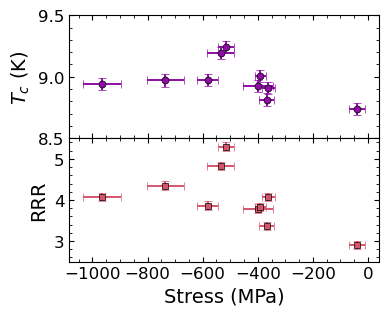

In [29]:
fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(4.0, 3.2), sharex=True,
    gridspec_kw={'hspace': 0.0},
)

plot_tc_rrr_vs_stress(
    stress, stress_err, Tc, Tc_err, RRR, RRR_err,
    ax_top=ax_top, ax_bot=ax_bot,
)

#fig.savefig('tc_rrr_vs_stress.pdf', bbox_inches='tight')